# Contrôles avant modélisation

## Objectif

Ce notebook vérifie que les datasets finaux sont prêts pour la modélisation, sans entraîner de modèle ni modifier les données. Il distingue les contrôles bloquants (structure, types, cible et valeurs infinies) des diagnostics à traiter dans le futur pipeline (valeurs manquantes, faible variance, déséquilibre et écarts train/test).

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Chemins des données ----------
PROCESSED_DIR = Path("../data/processed")
TRAIN_PATH = PROCESSED_DIR / "application_train_final_encoded.csv"
TEST_PATH = PROCESSED_DIR / "application_test_final_encoded.csv"

for data_path in [TRAIN_PATH, TEST_PATH]:
    if not data_path.is_file():
        raise FileNotFoundError(f"Fichier introuvable : {data_path.resolve()}")

## Chargement et aperçu

Les deux fichiers restent séparés. Le train contient `TARGET`, tandis que le test doit contenir exactement les mêmes variables explicatives, dans le même ordre.

In [22]:
# ---------- Chargement des données ----------
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

dimensions = pd.DataFrame({
    "jeu de données": ["train", "test"],
    "nombre de lignes": [len(df_train), len(df_test)],
    "nombre de colonnes": [df_train.shape[1], df_test.shape[1]],
})
display(dimensions)
print("Aperçu du train :")
display(df_train.head())
print("Aperçu du test :")
display(df_test.head())

,jeu de données,nombre de lignes,nombre de colonnes
0,train,307510,321
1,test,48744,320


Aperçu du train :


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,PREV_INSTAL_LATE_PAYMENT_RATIO_MEAN,PREV_INSTAL_MAX_DAYS_LATE,PREV_INSTAL_UNDERPAYMENT_RATIO_MEAN,PREV_INSTAL_PAYMENT_RATIO_MEAN,PREV_CC_HISTORY_RATIO,PREV_CC_UTILIZATION_MEAN,PREV_CC_EVER_SEVERE_DPD,PREV_POS_REMAINING_INSTALLMENTS_SUM,PREV_CC_BALANCE_LATEST_SUM,PREV_HAS_HISTORY
0,100002,1,0,0,1,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,1.0,0.000000,NaN,NaN,6.0,NaN,1
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,1.0,0.000000,NaN,NaN,1.0,NaN,1
2,100004,0,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,1.0,0.000000,NaN,NaN,0.0,NaN,1
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,1.0,0.111111,0.0,0.0,3.0,0.0,1
4,100007,0,0,0,1,0,121500.0,513000.0,21865.5,513000.0,...,0.3,12.0,0.0,1.0,0.000000,NaN,NaN,14.0,NaN,1


Aperçu du test :


,SK_ID_CURR,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,...,PREV_INSTAL_LATE_PAYMENT_RATIO_MEAN,PREV_INSTAL_MAX_DAYS_LATE,PREV_INSTAL_UNDERPAYMENT_RATIO_MEAN,PREV_INSTAL_PAYMENT_RATIO_MEAN,PREV_CC_HISTORY_RATIO,PREV_CC_UTILIZATION_MEAN,PREV_CC_EVER_SEVERE_DPD,PREV_POS_REMAINING_INSTALLMENTS_SUM,PREV_CC_BALANCE_LATEST_SUM,PREV_HAS_HISTORY
0,100001,0,0,1,0,135000.0,568800.0,20560.5,450000.0,0.018850,...,0.000000,0.0,0.0,1.0,0.0,NaN,NaN,0.0,NaN,1
1,100005,0,0,1,0,99000.0,222768.0,17370.0,180000.0,0.035792,...,0.111111,1.0,0.0,1.0,0.0,NaN,NaN,0.0,NaN,1
2,100013,0,1,1,0,202500.0,663264.0,69777.0,630000.0,0.019101,...,0.267974,21.0,0.0,1.0,0.0,NaN,NaN,0.0,NaN,1
3,100028,0,0,1,2,315000.0,1575000.0,49018.5,1575000.0,0.026392,...,0.049550,7.0,0.0,1.0,0.2,0.035934,0.0,0.0,37335.914,1
4,100038,0,1,0,1,180000.0,625500.0,32067.0,625500.0,0.010032,...,0.000000,0.0,0.0,1.0,0.0,NaN,NaN,0.0,NaN,1


## Contrôles structurels bloquants

`SK_ID_CURR` doit être présent, complet et unique. `TARGET` doit apparaître uniquement dans le train. Après retrait de la cible, les colonnes du train et du test doivent être strictement identiques. Un échec de l'une de ces assertions interdit de commencer la modélisation.

In [23]:
# ---------- Validation de la structure ----------
ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"

assert ID_COLUMN in df_train.columns and ID_COLUMN in df_test.columns
assert df_train[ID_COLUMN].notna().all() and df_test[ID_COLUMN].notna().all()
assert df_train[ID_COLUMN].is_unique and df_test[ID_COLUMN].is_unique
assert not df_train.columns.duplicated().any()
assert not df_test.columns.duplicated().any()
assert TARGET_COLUMN in df_train.columns
assert TARGET_COLUMN not in df_test.columns
assert df_train.drop(columns=TARGET_COLUMN).columns.tolist() == df_test.columns.tolist()
assert set(df_train[TARGET_COLUMN].dropna().unique()) == {0, 1}
assert df_train[TARGET_COLUMN].notna().all()

print("Tous les contrôles structurels sont réussis.")

Tous les contrôles structurels sont réussis.


## Types et valeurs non finies

Les variables doivent être numériques ou booléennes. Une valeur infinie est bloquante et signale généralement un calcul incorrect, par exemple une division par zéro.

In [24]:
# ---------- Contrôle des types ----------
feature_columns = [
    column for column in df_test.columns if column != ID_COLUMN
]
non_numeric_train = (
    df_train[feature_columns]
    .select_dtypes(exclude=["number", "bool"])
    .columns.tolist()
)
non_numeric_test = (
    df_test[feature_columns]
    .select_dtypes(exclude=["number", "bool"])
    .columns.tolist()
)
assert not non_numeric_train, f"Colonnes non numériques dans le train : {non_numeric_train}"
assert not non_numeric_test, f"Colonnes non numériques dans le test : {non_numeric_test}"

# ---------- Contrôle des valeurs infinies ----------
infinite_train = pd.Series({
    column: int(np.isinf(df_train[column].to_numpy()).sum())
    for column in feature_columns
})
infinite_test = pd.Series({
    column: int(np.isinf(df_test[column].to_numpy()).sum())
    for column in feature_columns
})
assert infinite_train.sum() == 0, infinite_train[infinite_train.gt(0)]
assert infinite_test.sum() == 0, infinite_test[infinite_test.gt(0)]
print("Toutes les variables sont numériques ou booléennes et aucune valeur infinie n'est présente.")

Toutes les variables sont numériques ou booléennes et aucune valeur infinie n'est présente.


## Valeurs manquantes

Les valeurs manquantes ne sont pas corrigées ici. Le tableau sert à identifier leur importance et les écarts entre train et test. L'imputation devra être intégrée au futur pipeline et ajustée uniquement sur le train.

In [25]:
# ---------- Analyse des valeurs manquantes ----------
missing_summary = pd.DataFrame({
    "train_missing_count": df_train[feature_columns].isna().sum(),
    "train_missing_pct": df_train[feature_columns].isna().mean().mul(100),
    "test_missing_count": df_test[feature_columns].isna().sum(),
    "test_missing_pct": df_test[feature_columns].isna().mean().mul(100),
})
missing_summary["missing_pct_gap"] = (
    missing_summary["train_missing_pct"]
    - missing_summary["test_missing_pct"]
).abs()
missing_summary = missing_summary.sort_values("train_missing_pct", ascending=False)

all_missing_train = missing_summary.index[
    missing_summary["train_missing_pct"].eq(100)
].tolist()
assert not all_missing_train, f"Colonnes entièrement vides dans le train : {all_missing_train}"
display(missing_summary.head(25).round(2))

,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct,missing_pct_gap
PREV_CC_UTILIZATION_MEAN,230449,74.94,34478,70.73,4.21
PREV_CC_EVER_SEVERE_DPD,229576,74.66,34231,70.23,4.43
PREV_CC_BALANCE_LATEST_SUM,229576,74.66,34231,70.23,4.43
BUREAU_EVER_RECENT_DPD_12M,215279,70.01,6433,13.20,56.81
BUREAU_EVER_SEVERE_DPD,215279,70.01,6433,13.20,56.81
COMMONAREA_AVG,214864,69.87,33495,68.72,1.16
COMMONAREA_MODE,214864,69.87,33495,68.72,1.16
COMMONAREA_MEDI,214864,69.87,33495,68.72,1.16
NONLIVINGAPARTMENTS_MODE,213513,69.43,33347,68.41,1.02
NONLIVINGAPARTMENTS_MEDI,213513,69.43,33347,68.41,1.02


## Variables constantes ou quasi constantes

Une variable constante n'apporte aucune information au modèle. Une variable quasi constante peut rester utile dans certains cas, mais elle doit être signalée. Le seuil informatif retenu ici est une modalité dominante dans au moins 99,9 % des lignes.

In [26]:
# ---------- Analyse de la variabilité ----------
unique_counts = df_train[feature_columns].nunique(dropna=False)
constant_columns = unique_counts[unique_counts.le(1)].index.tolist()
dominant_ratios = pd.Series({
    column: df_train[column].value_counts(dropna=False, normalize=True).iloc[0]
    for column in feature_columns
}, name="dominant_ratio")
quasi_constant_columns = (
    dominant_ratios[dominant_ratios.ge(0.999)]
    .sort_values(ascending=False)
    .to_frame()
)

print(f"Colonnes constantes : {len(constant_columns)}")
display(pd.DataFrame({"colonne constante": constant_columns}))
print(f"Colonnes quasi constantes au seuil de 99,9 % : {len(quasi_constant_columns)}")
display(quasi_constant_columns)

Colonnes constantes : 7


,colonne constante
0,CODE_GENDER__nan
1,NAME_INCOME_TYPE__nan
2,NAME_EDUCATION_TYPE__nan
3,NAME_FAMILY_STATUS__nan
4,NAME_HOUSING_TYPE__nan
5,WEEKDAY_APPR_PROCESS_START__nan
6,ORGANIZATION_TYPE__nan


Colonnes quasi constantes au seuil de 99,9 % : 37


,dominant_ratio
WEEKDAY_APPR_PROCESS_START__nan,1.000000
ORGANIZATION_TYPE__nan,1.000000
NAME_FAMILY_STATUS__nan,1.000000
CODE_GENDER__nan,1.000000
NAME_INCOME_TYPE__nan,1.000000
NAME_EDUCATION_TYPE__nan,1.000000
NAME_HOUSING_TYPE__nan,1.000000
OBS_30_CNT_SOCIAL_CIRCLE_ANOMALOUS,0.999997
OBS_60_CNT_SOCIAL_CIRCLE_ANOMALOUS,0.999997
FLAG_MOBIL,0.999997


## Répartition de la cible

La répartition de `TARGET` permet d'anticiper un éventuel déséquilibre de classes. Ce constat guidera plus tard le choix des métriques et la stratégie de validation, sans modifier artificiellement la cible à ce stade.

,effectif,pourcentage
TARGET,,
0,282686,91.93
1,24824,8.07


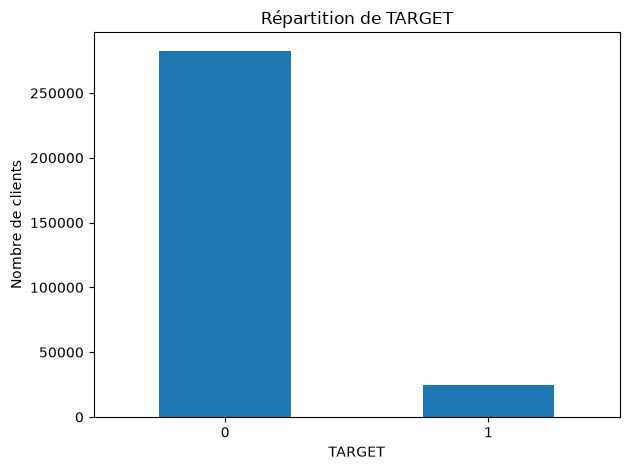

In [27]:
# ---------- Analyse de TARGET ----------
target_counts = df_train[TARGET_COLUMN].value_counts().sort_index()
target_summary = pd.DataFrame({
    "effectif": target_counts,
    "pourcentage": target_counts.div(len(df_train)).mul(100).round(2),
})
target_summary.index.name = TARGET_COLUMN
display(target_summary)

target_summary["effectif"].plot(
    kind="bar", title="Répartition de TARGET", ylabel="Nombre de clients"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Comparaison entre train et test

Deux diagnostics simples recherchent un décalage important : l'écart de taux de valeurs manquantes et l'écart de moyenne rapporté à l'écart-type du train. Ils ne constituent pas un test statistique complet, mais permettent de repérer rapidement les variables à examiner avant la modélisation.

In [28]:
# ---------- Écarts de valeurs manquantes ----------
display(
    missing_summary.sort_values("missing_pct_gap", ascending=False)
    .head(15)[["train_missing_pct", "test_missing_pct", "missing_pct_gap"]]
    .round(2)
)

# ---------- Écarts de moyenne standardisés ----------
train_means = df_train[feature_columns].mean()
test_means = df_test[feature_columns].mean()
train_standard_deviations = df_train[feature_columns].std().replace(0, np.nan)
standardized_mean_gap = (
    (test_means - train_means).abs() / train_standard_deviations
).sort_values(ascending=False).rename("standardized_mean_gap")
display(standardized_mean_gap.head(15).to_frame())

,train_missing_pct,test_missing_pct,missing_pct_gap
BUREAU_EVER_RECENT_DPD_12M,70.01,13.20,56.81
BUREAU_EVER_SEVERE_DPD,70.01,13.20,56.81
EXT_SOURCE_1,56.38,42.12,14.26
PREV_CC_BALANCE_LATEST_SUM,74.66,70.23,4.43
PREV_CC_EVER_SEVERE_DPD,74.66,70.23,4.43
PREV_CC_UTILIZATION_MEAN,74.94,70.73,4.21
PREV_POS_REMAINING_INSTALLMENTS_SUM,6.69,2.78,3.91
PREV_POS_EVER_SEVERE_DPD,6.68,2.77,3.91
PREV_APPROVED_CREDIT_TO_APPLICATION_RATIO_MEAN,6.01,2.48,3.52
PREV_POS_HISTORY_RATIO,5.35,1.94,3.41


,standardized_mean_gap
BUREAU_BB_HISTORY_RATIO,1.361122
BUREAU_BB_HISTORY_CREDIT_COUNT,1.040526
FLAG_EMAIL,0.457943
AMT_REQ_CREDIT_BUREAU_QRT,0.354417
NAME_CONTRACT_TYPE,0.293711
AMT_REQ_CREDIT_BUREAU_MON,0.281765
NAME_TYPE_SUITE__nan,0.223986
AMT_GOODS_PRICE,0.205111
AMT_CREDIT,0.204441
FLAG_DOCUMENT_3,0.168809


## Recherche d'un signal de fuite évident

Une corrélation presque parfaite avec `TARGET` peut révéler qu'une variable contient directement ou indirectement une information indisponible au moment de la prédiction. Ce contrôle ne prouve pas l'absence de fuite, mais signale les cas les plus évidents.

In [29]:
# ---------- Corrélations avec la cible ----------
correlation_columns = [
    column for column in feature_columns if column not in constant_columns
]
target_correlations = (
    df_train[correlation_columns]
    .corrwith(df_train[TARGET_COLUMN])
    .abs()
    .sort_values(ascending=False)
    .rename("absolute_target_correlation")
)
suspicious_correlations = target_correlations[target_correlations.ge(0.95)]
display(target_correlations.head(15).to_frame())
assert suspicious_correlations.empty, (
    f"Corrélations potentiellement suspectes : {suspicious_correlations.to_dict()}"
)

,absolute_target_correlation
EXT_SOURCE_3,0.178898
EXT_SOURCE_2,0.160453
EXT_SOURCE_1,0.155319
PREV_CC_UTILIZATION_MEAN,0.143841
PREV_CC_BALANCE_LATEST_SUM,0.090344
DAYS_BIRTH,0.078232
PREV_REFUSED_RATIO,0.077680
BUREAU_ACTIVE_CREDIT_RATIO,0.077343
DAYS_EMPLOYED,0.074952
PREV_INSTAL_LATE_PAYMENT_RATIO_MEAN,0.073338


## Préparation des objets de modélisation

L'identifiant est conservé séparément pour assurer la traçabilité, mais il est exclu de `X` et `X_test` car sa valeur arbitraire ne doit pas être apprise par le modèle. Aucune imputation ou normalisation n'est encore réalisée.

In [30]:
# ---------- Séparation des identifiants, variables et cible ----------
train_ids = df_train[ID_COLUMN].copy()
test_ids = df_test[ID_COLUMN].copy()
X = df_train.drop(columns=[ID_COLUMN, TARGET_COLUMN])
y = df_train[TARGET_COLUMN].copy()
X_test = df_test.drop(columns=ID_COLUMN)

assert X.columns.tolist() == X_test.columns.tolist()
assert len(X) == len(y) == len(train_ids)
assert len(X_test) == len(test_ids)
assert ID_COLUMN not in X.columns and TARGET_COLUMN not in X.columns

preparation_summary = pd.DataFrame({
    "objet": ["X", "y", "X_test"],
    "nombre de lignes": [len(X), len(y), len(X_test)],
    "nombre de colonnes": [X.shape[1], 1, X_test.shape[1]],
})
display(preparation_summary)
print("Les données sont structurellement prêtes pour la construction du pipeline.")

,objet,nombre de lignes,nombre de colonnes
0,X,307510,319
1,y,307510,1
2,X_test,48744,319


Les données sont structurellement prêtes pour la construction du pipeline.


## Conclusion et décisions pour la modélisation

Les contrôles bloquants sont réussis : clés uniques, train et test alignés, variables numériques ou booléennes, aucune valeur infinie et aucune fuite évidente.

| Constat | Décision pour le pipeline |
|---|---|
| 7 colonnes strictement constantes | Les supprimer : elles n'apportent aucun signal. |
| 30 autres colonnes quasi constantes | Comparer le même modèle avec et sans elles avant de décider. |
| Valeurs manquantes | Séparer entraînement et validation avant l'imputation. Apprendre la médiane sur l'entraînement uniquement, puis l'appliquer à la validation et au test. |
| `TARGET` déséquilibrée : 91,93 % de `0` et 8,07 % de `1` | Utiliser une séparation stratifiée, le ROC-AUC et tester les poids de classes. |
| Fort écart de valeurs manquantes pour `BUREAU_EVER_SEVERE_DPD` et `BUREAU_EVER_RECENT_DPD_12M` | Vérifier l'origine et comparer le modèle avec et sans ces deux variables. |

La partie entraînement servira à apprendre le modèle et les transformations. La validation contiendra des clients non utilisés pour l'apprentissage afin d'estimer la généralisation. Le test final, sans `TARGET`, restera réservé aux prédictions. Un pipeline garantira que l'imputation est réapprise correctement dans chaque pli de validation croisée.

## Réflexion sur le feature engineering final

Le dataset possède déjà 319 variables prédictives. Seules neuf caractéristiques métier complémentaires seront testées.

| Variable | Formule | Information apportée |
|---|---|---|
| `CREDIT_INCOME_RATIO` | `AMT_CREDIT / AMT_INCOME_TOTAL` | Poids du crédit par rapport au revenu |
| `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | Poids de l'annuité dans le revenu |
| `INCOME_PER_PERSON` | `AMT_INCOME_TOTAL / CNT_FAM_MEMBERS` | Revenu par membre du foyer |
| `CREDIT_GOODS_RATIO` | `AMT_CREDIT / AMT_GOODS_PRICE` | Part du bien financée par le crédit |
| `ANNUITY_CREDIT_RATIO` | `AMT_ANNUITY / AMT_CREDIT` | Intensité du remboursement |
| `EMPLOYED_AGE_RATIO` | `DAYS_EMPLOYED / DAYS_BIRTH` | Ancienneté professionnelle relative à l'âge |
| `EXT_SOURCE_MEAN` | moyenne des trois `EXT_SOURCE` disponibles | Synthèse des scores externes |
| `EXT_SOURCE_MISSING_COUNT` | nombre de `EXT_SOURCE` absentes | Disponibilité des scores externes |
| `BUREAU_DEBT_INCOME_RATIO` | `BUREAU_DEBT_SUM / AMT_INCOME_TOTAL` | Dette externe rapportée au revenu |

Les dénominateurs nuls seront remplacés par des valeurs manquantes avant les divisions. Les mêmes calculs seront appliqués au train et au test, sans retirer les variables originales.

Deux expériences utiliseront la même séparation, le même modèle et les mêmes métriques :

1. modèle de référence avec les variables actuelles ;
2. modèle avec les neuf variables supplémentaires.

Ces variables seront conservées uniquement si elles améliorent la validation.